# Experiment 2 (MNIST): Lipschitz Estimation on Real Classifiers

## Motivation and relation to Experiment 1

Experiment 1 (`toy_lipschitz`, sibling folder) built three ways to estimate
a function's **Lipschitz constant** `L` -- how much its output can change
for a given change in input, `|f(x')-f(x)| <= L * ||x'-x||` -- and
validated all three against a **known, closed-form ground truth** `L*` on
a toy 1D/2D regression problem. It also showed that replacing plain
Euclidean distance with a **Mahalanobis distance** fit from the data
itself can substantially change (and, there, improve) the resulting
estimate.

This experiment scales the same three estimators up to real classifiers
trained on MNIST. **There is no closed-form `L*` here** -- a trained
neural network's exact Lipschitz constant is not analytically knowable in
general. So this experiment cannot ask "how close is the estimate to the
truth"; it can only ask two weaker but still meaningful questions:

1. **Do the three independent sub-methods (pairwise, local-perturbation,
   gradient-norm) roughly agree with each other?** Disagreement doesn't
   necessarily mean a bug (see this notebook's results below -- it turns
   out they *don't* agree well here, and that's a real, reportable
   finding, not an error), but it tells you how much to trust any single
   number.
2. **Is the estimate stable under resampling?** An estimate that swings
   wildly depending on which random subset of the data it was computed
   from is fitting sampling noise, not a real property of the model.

These two checks -- sub-method agreement and subsample stability --
replace Experiment 1's "compare to `L*`" checkpoint everywhere in this
notebook.

**Out of scope for this experiment** (may return in a later one):
adversarial examples, FGSM/PGD attacks, robustness mitigations (weight
decay, spectral norm, gradient penalty, adversarial training, input
smoothing), Fashion-MNIST.

## What's being measured

Instead of a scalar regression output `f(x)` (Experiment 1), a classifier
outputs 10 logits. The Lipschitz estimators here are applied to the
**margin function**, `margin(x) = logit[y_true] - max(logit[j] for j !=
y_true)` -- the natural classifier analogue of a scalar output, and the
quantity robustness actually depends on: the margin crossing zero is
exactly where the predicted class flips.

Three classifiers are trained (logistic regression, a small MLP, a small
CNN), and for each, all three sub-methods are computed twice: once under
plain Euclidean distance, once under a **ridge-regularized Mahalanobis
distance** fit from MNIST's own pixel covariance (raw pixel covariance is
exactly singular -- many border pixels are 0 in every image -- so it must
be regularized before it can be inverted; how much regularization to use
is itself selected by a data-driven sweep, mirroring Experiment 1's
polynomial-embedding-degree selection).

This is a thin driver notebook -- all reusable logic lives in the sibling
`.py` modules (`data.py`, `models.py`, `estimators.py`, `distance.py`,
`run_experiment.py`, `plots.py`); this notebook only calls into them and
displays the results. See `README.md` in this folder for a plain
file-by-file reference of the codebase and the full write-up of what was
found.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt

from mnist_lipschitz import run_experiment, plots

## Running the full experiment

`run_mnist_experiment()` runs, in order:

1. **Train** logistic regression, MLP, and a small CNN on full MNIST.
2. **Euclidean-distance estimates**: all three sub-methods (pairwise,
   local-perturbation, gradient-norm), on all three models, evaluated on a
   fixed set of held-out test points.
3. **Epsilon selection**: fit the full-training-set pixel covariance,
   sweep several candidate ridge strengths (`epsilon`), and pick the
   smallest one whose regularized covariance is well-conditioned *and*
   whose resulting estimate is stable across independent random
   subsamples of the training data.
4. **Mahalanobis-distance estimates**: the same three sub-methods on the
   same three models, now under the selected Mahalanobis distance.
5. **Save** everything to `results/` (`mnist_experiment_results.json` for
   scalar summaries, `mnist_experiment_arrays.npz` for the full per-point
   arrays).

This takes about a minute on CPU.

In [2]:
results = run_experiment.run_mnist_experiment()

=== Step 1: training models ===
  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254
  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299
  epoch  5/15  train loss 0.3119


  epoch  6/15  train loss 0.2999
  epoch  7/15  train loss 0.2914


  epoch  8/15  train loss 0.2845
  epoch  9/15  train loss 0.2793


...

  epsilon=10         mean L_hat=27.5778  std=0.2533  cv=0.0092


  epsilon=100        mean L_hat=85.0278  std=0.5913  cv=0.0070
selected epsilon=0.01 (smallest meeting cond<=10000, cv<=0.05)

=== Step 4: Mahalanobis-distance estimators (epsilon=0.01) ===


  logistic_regression: pairwise=0.9979  local_max=0.1702  grad_max=9.4199  grad_mean=5.4862


  mlp: pairwise=1.1760  local_max=0.3674  grad_max=16.0362  grad_mean=9.6752


  cnn: pairwise=1.1220  local_max=0.1897  grad_max=9.7031  grad_mean=5.3170

Saved results to /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/results


## Model accuracies

Sanity check before looking at any Lipschitz numbers: did training
actually work? (Thresholds validated in `tests/test_models.py`: logistic
regression > 90%, MLP > 96%, CNN > 98%, each with headroom below what's
typically observed.)

In [3]:
for name, acc in results["accuracies"].items():
    print(f"{name:20s} train_acc={acc['train']:.4f}  test_acc={acc['test']:.4f}")

logistic_regression  train_acc=0.9287  test_acc=0.9270
mlp                  train_acc=0.9931  test_acc=0.9782
cnn                  train_acc=0.9889  test_acc=0.9865


## Euclidean-distance estimates: do the three sub-methods agree?

Plain Euclidean distance in raw pixel space, for all three models. Each
panel below is one model; the three bars are the three independently
implemented sub-methods, on a log scale (they live on very different
natural scales here, which is itself part of the finding).

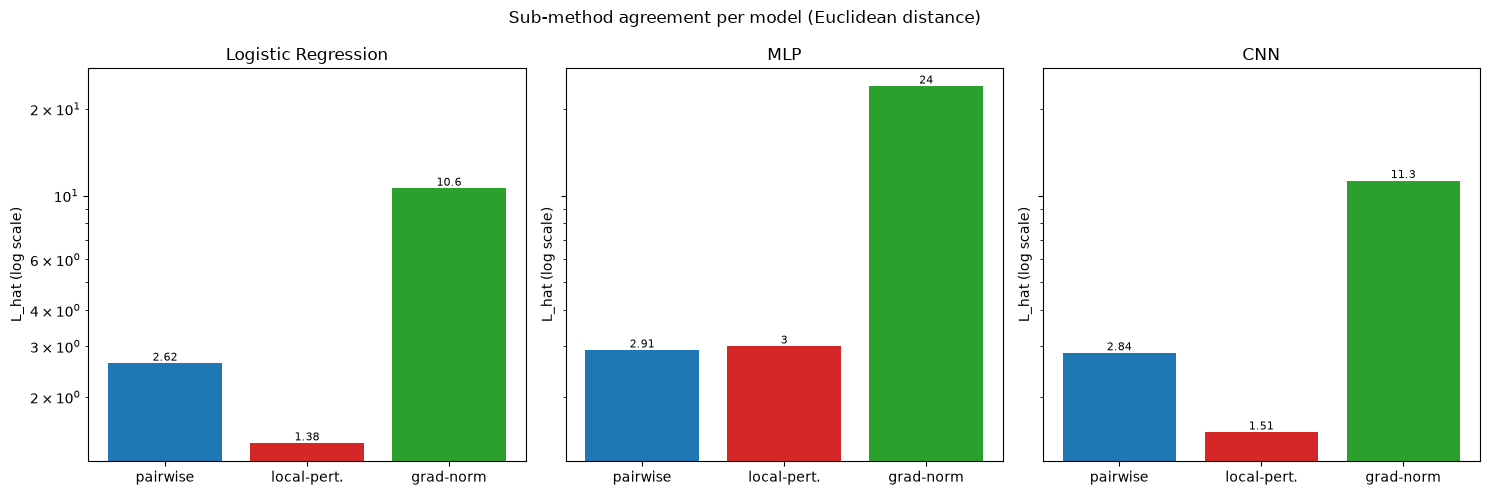

In [4]:
fig_agree_euclidean = plots.plot_submethod_agreement(
    results["euclidean_results"], metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_euclidean.png")

## Epsilon selection

MNIST's raw pixel covariance is exactly singular (constant-zero border
pixels), so it can't be inverted directly. The plot below shows, across a
range of candidate `epsilon` values (log scale): the condition number of
the ridge-regularized covariance (should shrink as epsilon grows -- always
true, this is a deterministic mathematical fact) and the coefficient of
variation of the resulting estimate across independent random subsamples
of the training set (should not get *worse* as epsilon grows -- this one
is an empirical check, not a mathematical guarantee, and is where a real
implementation bug would show up first). The selected epsilon (dashed
line) is the smallest one meeting both a condition-number bound and a
stability bound.

selected epsilon = 0.01


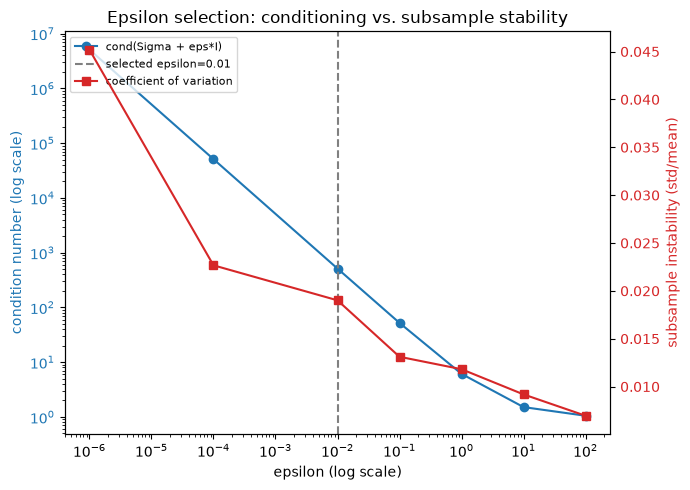

In [5]:
fig_epsilon = plots.plot_epsilon_sweep(
    results["epsilon_values"], results["cond_numbers"], results["cv_values"],
    selected_epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "epsilon_sweep.png")
print(f"selected epsilon = {results['selected_epsilon']:g}")

## Why regularization is needed: the covariance's eigenvalue spectrum

The epsilon sweep above is a downstream *consequence* of a more basic
fact: MNIST's raw pixel covariance `Sigma` is singular. This section
makes that directly visible by plotting `Sigma`'s eigenvalue spectrum
(sorted largest to smallest, log scale), together with the
ridge-regularized spectrum `Sigma + epsilon*I` at the epsilon selected
above.

`Sigma + epsilon*I` has the *same eigenvectors* as `Sigma` -- adding
`epsilon*I` only shifts every eigenvalue up by exactly `epsilon` -- so the
two curves below differ only where `epsilon` actually matters: once an
eigenvalue of `Sigma` drops below `epsilon`, the regularized curve
flattens out at `epsilon` instead of continuing to fall, which is exactly
what keeps `(Sigma + epsilon*I)^{-1}` (the precision matrix used for
Mahalanobis distance) from blowing up in those directions.

largest eigenvalue:  5.1169
smallest eigenvalue: -6.7497e-16
eigenvalues below 1e-6: 94 / 784


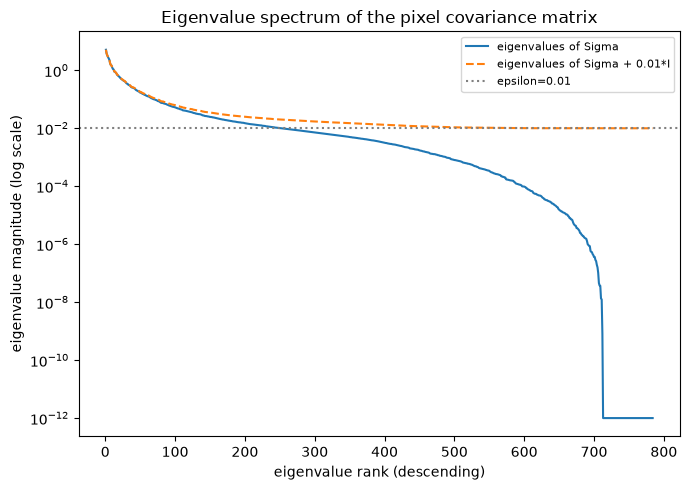

In [6]:
eigenvalues = results["covariance_eigenvalues"]
fig_eigenvalues = plots.plot_covariance_eigenvalues(
    eigenvalues, epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "covariance_eigenvalues.png")

n_near_zero = (eigenvalues < 1e-6).sum().item()
print(f"largest eigenvalue:  {eigenvalues[0].item():.4f}")
print(f"smallest eigenvalue: {eigenvalues[-1].item():.4e}")
print(f"eigenvalues below 1e-6: {n_near_zero} / {len(eigenvalues)}")

## Mahalanobis vs. Euclidean: does the metric change the estimates?

This is the central question of the experiment -- the same question
Experiment 1 asked on the toy problem, now on real classifiers. Same
three models, same three sub-methods, only the distance metric changes.

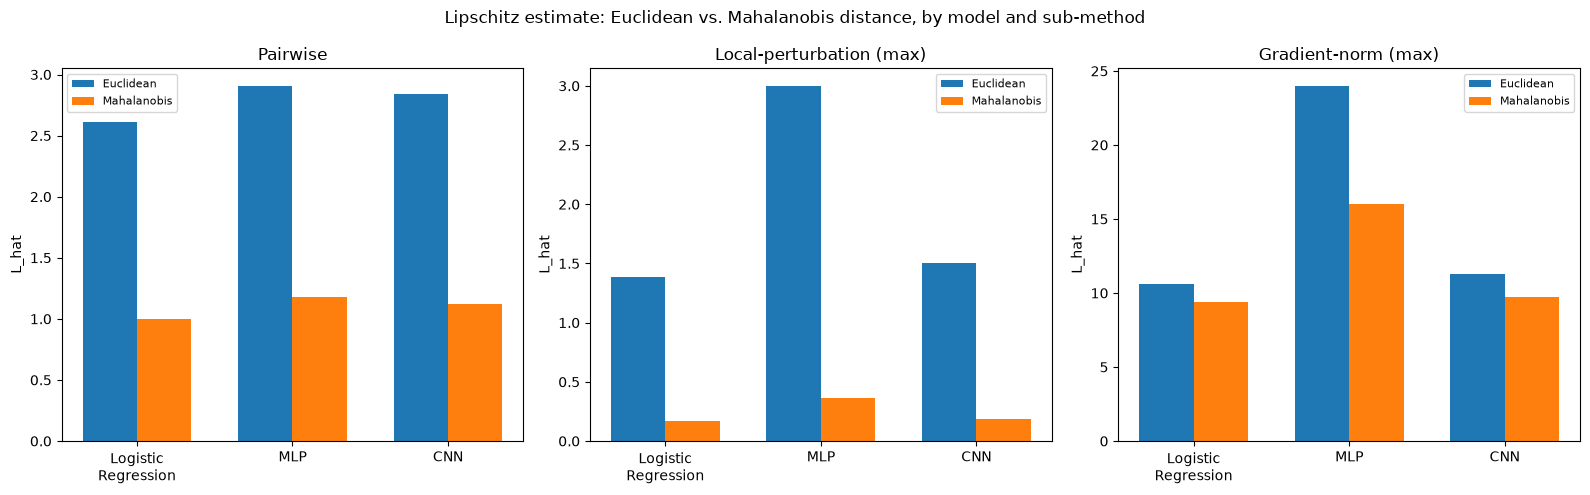

In [7]:
fig_compare = plots.plot_euclidean_vs_mahalanobis(
    results["euclidean_results"], results["mahalanobis_results"],
    save_path=run_experiment.RESULTS_DIR / "euclidean_vs_mahalanobis.png")

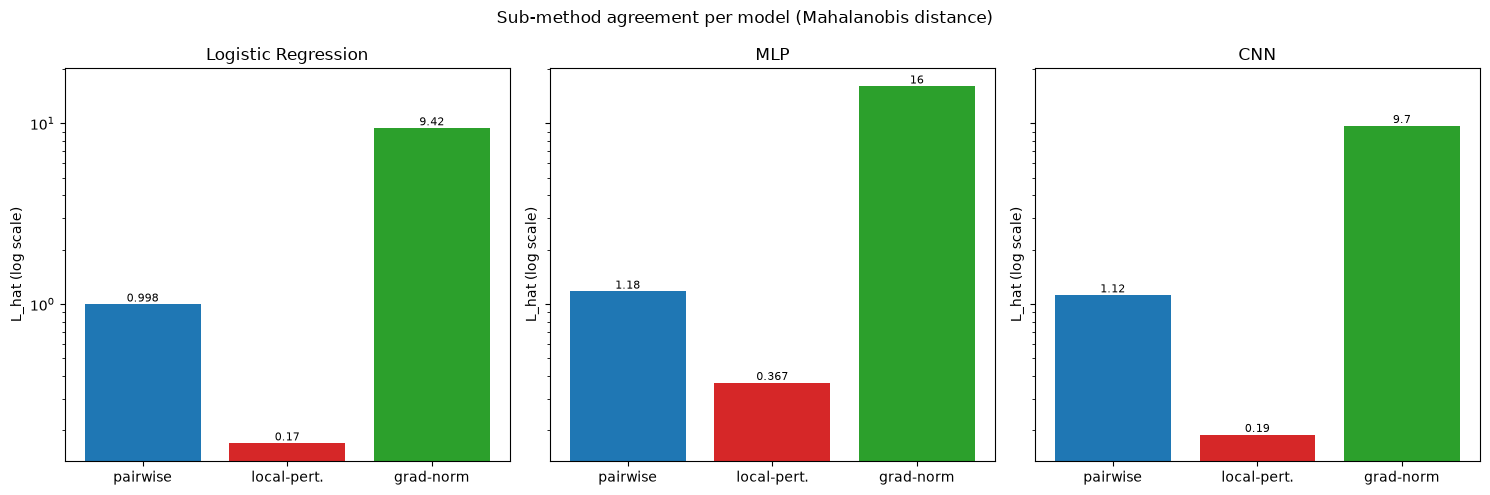

In [8]:
fig_agree_mahalanobis = plots.plot_submethod_agreement(
    results["mahalanobis_results"], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_mahalanobis.png")

## Summary and status

See `README.md` in this folder for the full write-up, including the
actual measured numbers behind the plots above, the design decisions made
along the way (activation choice, pair-sampling strategy, the precision
vs. its inverse convention in the gradient-norm dual norm, why ridge
regularization was used before trying PCA truncation, how epsilon was
selected), and an honest account of what was and wasn't expected --
including that the three sub-methods agree much less closely here than
they did in Experiment 1's toy setting, and that this gap widens rather
than narrows under the Mahalanobis metric. Those results are reported
as observed, not smoothed into a cleaner story.

This is Experiment 2 of the Lipschitz-diagnostics project. Adversarial
examples, robustness mitigations, and Fashion-MNIST are explicitly out of
scope here and may be the subject of a later experiment.